In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from bayesflow.diagnostics.plots import Recovery, CalibrationECDF

Defaulting to JAX.
To override, set the KERAS_BACKEND environment variable before importing bayesflow.
See: https://keras.io/getting_started/#configuring-your-backend
INFO:2026-03-13 09:40:17,493:jax._src.xla_bridge:830: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:bayesflow:Using backend 'jax'


## The `Metric` class

In [3]:
estimates = {"mu": np.random.normal(size=(50, 200, 3)), "sigma": np.random.normal(size=(50, 200, 3))}
targets   = {"mu": np.random.normal(size=(50, 3)), "sigma": np.random.normal(size=(50, 3))}

In [4]:
rmse = bf.diagnostics.metrics.RootMeanSquaredError(normalize="range")
result = rmse(estimates, targets)

In [5]:
print(result["metric_name"])       # NRMSE
print(result["variable_names"])    # ['mu_0', 'mu_1', 'mu_2']
print(result["values"])            # array of shape (3,)

NRMSE
['mu_0', 'mu_1', 'mu_2', 'sigma_0', 'sigma_1', 'sigma_2']
[0.36790041 0.32431251 0.32026253 0.32417122 0.28241508 0.27752397]


In [6]:
def mean_absolute_error(estimates, targets):
    values = np.mean(np.abs(estimates.mean(axis=1) - targets), axis=0)
    return {
        "values": values,
        "metric_name": "MAE",
        "variable_names": estimates.variable_names,
    }

In [7]:
mae = bf.diagnostics.metrics.CustomMetric(mean_absolute_error)
result = mae(estimates, targets)

In [8]:
print(result["metric_name"])
print(result["variable_names"])
print(result["values"])

MAE
['mu_0', 'mu_1', 'mu_2', 'sigma_0', 'sigma_1', 'sigma_2']
[0.8417921  0.86610115 0.73720626 0.71936264 0.74876983 0.7688832 ]


## The `Plot` class

Here we use `Recovery` as an example

In [10]:
class Recovery(bf.diagnostics.plots.Plot):
  def __init__(self, point_agg=np.median, color="#132a70", **kwargs):
      super().__init__(**kwargs)
      self.point_agg = point_agg
      self.color = color

  def create(self, estimates, targets) -> plt.Figure:
      samples = self._preprocess(estimates, targets)
      est, tgt = samples["estimates"], samples["targets"]
      num_vars = est.shape[-1]

      num_col = self.num_col or num_vars
      num_row = self.num_row or 1
      fig, axes = plt.subplots(num_row, num_col, figsize=self.figsize or (4 * num_col, 4))

      point_est = self.point_agg(est, axis=1)  # (num_datasets, num_variables)

      for i, ax in enumerate(np.atleast_1d(axes).flat):
          ax.scatter(tgt[:, i], point_est[:, i], alpha=0.5, color=self.color, s=15)
          lo, hi = tgt[:, i].min(), tgt[:, i].max()
          ax.plot([lo, hi], [lo, hi], "k--", lw=1)
          ax.set_xlabel("Ground truth", fontsize=self.label_fontsize)
          ax.set_ylabel("Estimate",     fontsize=self.label_fontsize)
          ax.set_title(est.variable_names[i], fontsize=self.title_fontsize)
          ax.tick_params(labelsize=self.tick_fontsize)

      fig.tight_layout()
      return fig

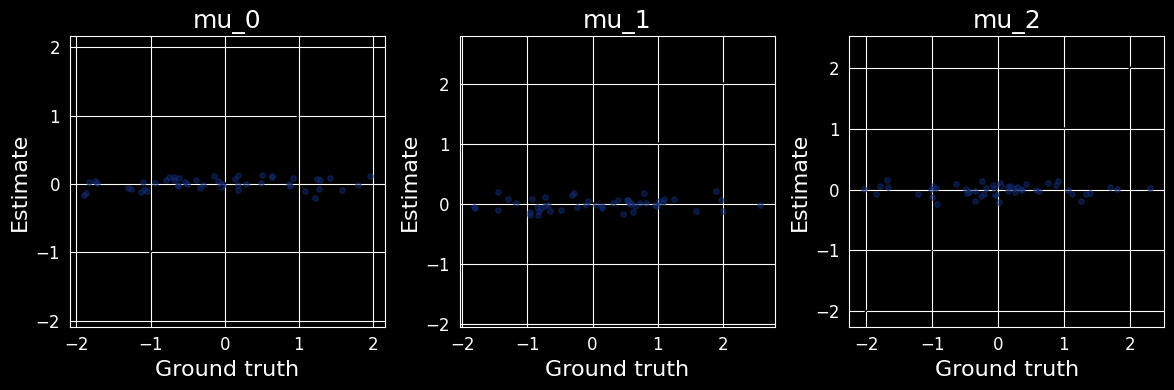

In [11]:
recovery = Recovery(point_agg=np.median, color="#132a70", num_col=3)
fig = recovery(estimates, targets)